In [1]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score
from category_encoders.count import CountEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

In [2]:
warnings.filterwarnings('ignore')

suppress the warnings / later needed for numpy.exp()

## Loading the dataset

In [3]:
training = pd.read_csv("data/dontgetkicked/training.csv")
testing = pd.read_csv("data/dontgetkicked/test.csv")

## Preprocessing - train/validation/test split

<h5>train.PurchDate < valid.PurchDate < test.PurchDate</h5>

In [4]:
class PipeProcess:
    def triplesplit(self, X, field):
        normalizer = StandardScaler()
        X = pd.DataFrame(X)
        X[field] = pd.to_datetime(X[field])
        X.sort_values(by=field, inplace=True)
        X.reset_index(drop=True, inplace=True)
        X[field] = pd.to_numeric(X[field])
        
        ratio_idx = len(X) // 3
        train_samples = X.iloc[:ratio_idx]
        valid_samples = X.iloc[ratio_idx:ratio_idx*2]
        test_samples = X.iloc[ratio_idx*2:]
        return train_samples, valid_samples, test_samples

    def normalize(self, train, valid, test):
        scaler = StandardScaler()
        X_train = scaler.fit_transform(train)
        X_valid = scaler.transform(valid)
        X_test = scaler.transform(test)
        return X_train, X_valid, X_test

    def extract(self, x, field):
        for idx in x:
            y = idx[field]
            newx = idx.drop(columns=field)
            yield newx
            yield y

    def encode(self, x):
        train = x[0]
        enc = CountEncoder()
        enc.fit(train)

        for idx in x:
            idx = enc.transform(idx)
            idx.dropna(inplace=True)
            yield idx

    def process(self, X, field):
        train, valid, test = self.triplesplit(X, field)
        train, valid, test = self.encode([train, valid, test])
        
        return train, valid, test

In [5]:
%%time
pp = PipeProcess()
train, valid, test = pp.process(training, "PurchDate")
X_train, y_train, X_valid, y_valid, X_test, y_test = pp.extract([train, valid, test], "IsBadBuy")
X_train, X_valid, X_test = pp.normalize(X_train, X_valid, X_test)

CPU times: user 532 ms, sys: 22.8 ms, total: 555 ms
Wall time: 557 ms


# <small>Task 2. MLP model</small>
Blueprint:<br>
<code>model = MLP(n_hidden=100, activation="sigmoid")</code><br>
<code>model.fit(Xtrain, ytrain)</code><br>
<code>model.predict_proba(Xvalid)</code><br>

Specifications: SGD, mini-batch size 32, np.arctan activation, BCE loss function.

Later tasks: +activaion functions: relu, cosine

In [6]:
class MLP:
    def __init__(self, n_hidden, n_output=1, lr=0.1, activation="sigmoid", epochs=10):
        self.lr = lr
        self.epochs = epochs
        self.batch_size = 32
        self.hidden_nodes = n_hidden
        self.output_nodes = n_output
        
        self.bias_h = np.random.uniform(-1, 1, (self.hidden_nodes, 1))
        self.bias_o = np.random.uniform(-1, 1, (self.output_nodes, 1))
        self.weights_ih = None
        self.weights_ho = None

        self.activation_name = activation
        if activation == "sigmoid":
            self.activation = self.sigmoid
        elif activation == "relu":
            self.activation = self.relu
        elif activation == "arctan":
            self.activation = self.arctan
        elif activation == "cosine":
            self.activation = self.cosine
        
    def sigmoid(self, x):  return 1/(1 + np.exp(-x))
    def relu(self, x):     return np.maximum(0, x)
    def arctan(self, x):   return np.arctan(x)
    def cosine(self, x):   return np.cos(x)

    def getderivatives(self, hidden_sum):
        if self.activation_name == "sigmoid":
            hidden_out = self.sigmoid(hidden_sum)
            return hidden_out * (1 - hidden_out)
            
        elif self.activation_name == "relu":
            return (hidden_sum > 0).astype(float)
            
        elif self.activation_name == "arctan":
            return 1 / (1 + np.power(hidden_sum, 2))
            
        elif self.activation_name == "cosine":
            return -np.sin(hidden_sum)

    
    def feedforward(self, inputs):
        inputs = np.array(inputs)
        self.hidden_sum = np.matmul(self.weights_ih, np.transpose(inputs)) + self.bias_h
        self.hidden_out = self.activation(self.hidden_sum)
        self.output_sum = np.matmul(self.weights_ho, self.hidden_out) + self.bias_o
        self.output_out = self.sigmoid(self.output_sum)
        return self.output_out.reshape(-1, 1)

    
    def backprop(self, X, y):
        y = np.array(y)
        X = np.array(X)
        self.feedforward(X)
        output_deltas = y - self.output_out
        hidden_errors = np.matmul(self.weights_ho.T, output_deltas)
        hidden_deltas = hidden_errors * self.getderivatives(self.hidden_sum)

        batch_size = X.shape[0]
        self.weights_ho += self.lr * np.matmul(output_deltas, self.hidden_out.T) / batch_size
        self.weights_ih += self.lr * np.matmul(hidden_deltas, X) / batch_size
        self.bias_h += self.lr * np.sum(hidden_deltas, axis=1, keepdims=True) / batch_size
        self.bias_o += self.lr * np.sum(output_deltas, axis=1, keepdims=True) / batch_size


    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        if self.weights_ih is None:
            self.input_nodes = X.shape[1]
            limit = np.sqrt(6 / (self.input_nodes + self.output_nodes))
            self.weights_ih = np.random.uniform(-limit, limit, (self.hidden_nodes, self.input_nodes))
            self.weights_ho = np.random.uniform(-limit, limit, (self.output_nodes, self.hidden_nodes))

        for epoch in range(self.epochs):
            indices = np.arange(X.shape[0])
            np.random.shuffle(indices)
            X = X[indices]
            y = y[indices]

            for i in range(0, X.shape[0], self.batch_size):
                X_batch = X[i:i+self.batch_size]
                y_batch = y[i:i+self.batch_size]
                self.backprop(X_batch, y_batch)


    def predict_proba(self, X):
        if self.weights_ih is None:
            print("Train the model first.")
            return
        X = np.array(X)
        output = self.feedforward(X)
        prob_0 = 1 - output    
        return np.hstack([prob_0, output])

    def predict(self, X):
        probas = self.predict_proba(X)[:, 1]
        return (probas >= 0.5).astype(int)

Model only supports sigmoid and np.arctan activation functions for hidden layers.

In [7]:
nn = MLP(n_hidden=100, lr=0.1, activation="sigmoid")
nn.fit(X_train, y_train)

In [8]:
print(f"Accuracy score: {accuracy_score(nn.predict(X_train), y_train)}")

Accuracy score: 0.9094365710335293


# <small>Gini Impurity score</small>

With your MLP module and careful network engineering, you must obtain at least a 0.15 Gini score on the validation dataset. You can train for more than 1 epoch, use different activation functions, and different optimizers (like SGD or Adam).

In [9]:
def gini_score(y_true, y_pred):
    roc = roc_auc_score(y_pred, y_true)
    return (2*roc)-1

In [10]:
nnsig = MLP(n_hidden=100, lr=0.1, activation="sigmoid")
nnarc = MLP(n_hidden=100, lr=0.1, activation="arctan")
nnsig.fit(X_train, y_train)
nnarc.fit(X_train, y_train)

In [11]:
print(f"Sigmoid Gini Score: {gini_score(nnsig.predict_proba(X_valid)[:, 1], y_valid)}")
print(f"np.arctan Gini Score: {gini_score(nnarc.predict_proba(X_valid)[:, 1], y_valid)}")

Sigmoid Gini Score: 0.32996507050924917
np.arctan Gini Score: 0.30078671244220967


<h4>In any case, they are both higher than 0.15<br>
Sigmoid and np.arctan are activation functions for hidden layers.</h4>

# <small>sklearn.neural_network.MLPClassifier</small>

Is it better than my module? If so, why?

In [12]:
mlp = MLPClassifier(
    hidden_layer_sizes=100, 
    activation='logistic', 
    batch_size=32,
    learning_rate='constant', 
    learning_rate_init=0.1
)
mlp.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.",100
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'logistic'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",32
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.1
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


<h4>With all these parameters I tuned this model according to my model's parameters, because that's how we can compare them accurately.</h4>

#### accuracy_score

In [13]:
print(f'MLPClassifier Gini score: {gini_score(mlp.predict_proba(X_valid)[:, 1], y_valid)}')
print(f'MLPClassifier accuracy score: {accuracy_score(y_valid, mlp.predict(X_valid))}')

MLPClassifier Gini score: 0.32582631271295237
MLPClassifier accuracy score: 0.8977327124766091


<h4>Is that better than my model? No, my gini score was a bit higher, on the accuracy score - both are kinda the same.</h4>

# <small>Different activation functions</small>

Implement and try different activation functions: sigmoid, ReLU, cosine. Remember that you have to derive gradients for each different activation function. Which activation function gives the best performance on the validation dataset?

<h4>I implemented all the activation functions in the beginning/above model, to not to rewrite the whole model here again, so I'll just use these functions now.</h4>

In [14]:
results = pd.DataFrame(columns=['activations', 'metrics', 'score'])

In [15]:
for act in ['sigmoid', 'relu', 'arctan', 'cosine']:
    model = MLP(n_hidden=100, lr=0.1, activation=act)
    model.fit(X_train, y_train)

    preds = model.predict(X_valid)
    score = accuracy_score(preds, y_valid)
    gini = gini_score(model.predict_proba(X_valid)[:, 1], y_valid)
    idx = len(results)
    results.loc[idx] = [act, "accuracy score", score]
    results.loc[idx+1] = [act, "gini", gini]

In [16]:
results

,activations,metrics,score
0,sigmoid,accuracy score,0.897820
1,sigmoid,gini,0.343261
2,relu,accuracy score,0.884155
3,relu,gini,0.313531
4,arctan,accuracy score,0.897167
5,arctan,gini,0.287736
6,cosine,accuracy score,0.872405
7,cosine,gini,0.280924


### visualizing the results

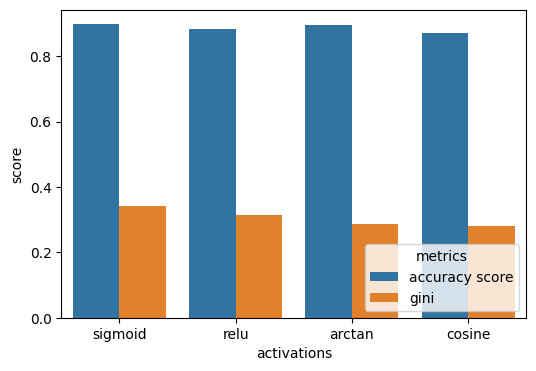

In [17]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(results, x='activations', y='score', hue='metrics')
sns.move_legend(ax, "lower right")
plt.show()

I like visualizing the results, cuz it's easier to read the results rather than mathing in the brain with raw numbers.

# <small>Best Model</small>

Take the best model and estimate its performance on the test dataset: check the Gini scores on all three datasets for your best model: training Gini, valid Gini, test Gini. Do you see a drop in performance when comparing the valid quality to the test quality? Is your model overfitting or not? Explain.

<h4>my best model was my own MLP with sigmoid activation function.</h4>

In [18]:
model = MLP(n_hidden=100, lr=0.1, activation="sigmoid")
gini_results = pd.DataFrame(columns=['dataset', 'gini_score'])

def namestr(obj, namespace):
    return [name for name in namespace if namespace[name] is obj]

def test(train, valid, test):
    model.fit(train[0], train[1])

    preds = model.predict_proba(train[0])[:, 1]
    gini = gini_score(preds, train[1])
    gini_results.loc[len(gini_results)] = ["training", gini]
    
    preds = model.predict_proba(valid[0])[:, 1]
    gini = gini_score(preds, valid[1])
    gini_results.loc[len(gini_results)] = ["validation", gini]
    
    preds = model.predict_proba(test[0])[:, 1]
    gini = gini_score(preds, test[1])
    gini_results.loc[len(gini_results)] = ["test", gini]


test([X_train, y_train], [X_valid, y_valid], [X_test, y_test])
print(f'Gini scores for each dataset:\n{gini_results}')

Gini scores for each dataset:
      dataset  gini_score
0    training    0.396058
1  validation    0.333302
2        test    0.187649


<h3>Yes, there is a significant drop in performance, specfically from validation to test dataset (<small>but still higher than 0.15, aye</small>). I think my model IS overfitted (<small>significantly</small>), because that drop in performance tells it.<br></h3>
<h3>Why?</h3>

<strong>-If you've paid attention in the begging of the notebook I've split the dataset by timestamp feature, by 33% ratio. When you split the data by timestamp there are a lot of unseen categories the later the dataset is. That's the exact reason why gini score on test dataset significantly dropped, because in the test dataset there are even more unseen categories/classes compared to validation dataset which takes place just after training dataset - which, I trained my encoder on, to categorize my categorical features.</strong>

# <small>ADAM Optimization</small>
<h4>Implement the Adam algorithm to tune the parameters of the model.</h4> - easy peasy lemon squeezy

In [19]:
class MLP_ADAM:
    def __init__(self, n_hidden, n_output=1, lr=0.1, activation="sigmoid", epochs=10):
        self.t = 0
        self.lr = lr
        self.e = 1e-8
        self.epochs = epochs
        self.batch_size = 32
        self.hidden_nodes = n_hidden
        self.output_nodes = n_output

        self.weights_ih = None
        self.weights_ho = None
        self.bias_h = np.random.uniform(-1, 1, (self.hidden_nodes, 1))
        self.bias_o = np.random.uniform(-1, 1, (self.output_nodes, 1))

        self.beta_1 = 0.9
        self.beta_2 = 0.999
        self.m_b_h = np.zeros((self.hidden_nodes, 1))
        self.m_b_o = np.zeros((self.output_nodes, 1))
        self.v_b_h = np.zeros((self.hidden_nodes, 1))
        self.v_b_o = np.zeros((self.output_nodes, 1))
        
        self.activation_name = activation
        if activation == "sigmoid":
            self.activation = self.sigmoid
        elif activation == "relu":
            self.activation = self.relu
        elif activation == "arctan":
            self.activation = self.arctan
        elif activation == "cosine":
            self.activation = self.cosine
        
    def sigmoid(self, x):  return 1/(1 + np.exp(-x))
    def relu(self, x):     return np.maximum(0, x)
    def arctan(self, x):   return np.arctan(x)
    def cosine(self, x):   return np.cos(x)

    def getderivatives(self, hidden_sum):
        if self.activation_name == "sigmoid":
            hidden_out = self.sigmoid(hidden_sum)
            return hidden_out * (1 - hidden_out)
            
        elif self.activation_name == "relu":
            return (hidden_sum > 0).astype(float)
            
        elif self.activation_name == "arctan":
            return 1 / (1 + np.power(hidden_sum, 2))
            
        elif self.activation_name == "cosine":
            return -np.sin(hidden_sum)
    
    def feedforward(self, inputs):
        inputs = np.array(inputs)
        self.hidden_sum = np.matmul(self.weights_ih, np.transpose(inputs)) + self.bias_h
        self.hidden_out = self.activation(self.hidden_sum)
        self.output_sum = np.matmul(self.weights_ho, self.hidden_out) + self.bias_o
        self.output_out = self.sigmoid(self.output_sum)
        return self.output_out.reshape(-1, 1)

    
    def backprop(self, X, y):
        y = np.array(y)
        X = np.array(X)
        self.feedforward(X)
        batch_size = X.shape[0]

        # gradients
        output_deltas = y - self.output_out
        hidden_errors = np.matmul(self.weights_ho.T, output_deltas)
        hidden_deltas = hidden_errors * self.getderivatives(self.hidden_sum)
        self.g_w_ho = np.matmul(output_deltas, self.hidden_out.T) / batch_size
        self.g_b_o = np.sum(output_deltas, axis=1, keepdims=True) / batch_size
        self.g_w_ih = np.matmul(hidden_deltas, X) / batch_size
        self.g_b_h = np.sum(hidden_deltas, axis=1, keepdims=True) / batch_size

        self.t += 1
        beta_1_p = (1 - np.power(self.beta_1, self.t))
        beta_2_p = (1 - np.power(self.beta_2, self.t))

        # HIDDEN LAYER
        # calculate: m_t; v_t
        self.m_w_ih = self.beta_1 * self.m_w_ih + (1 - self.beta_1) * self.g_w_ih
        self.m_b_h = self.beta_1 * self.m_b_h + (1 - self.beta_1) * self.g_b_h
        self.v_w_ih = self.beta_2 * self.v_w_ih + (1 - self.beta_2) * np.power(self.g_w_ih, 2)
        self.v_b_h = self.beta_2 * self.v_b_h + (1 - self.beta_2) * np.power(self.g_b_h, 2)

        # calculate: delta_m_t; delta_v_t
        d_m_w_ih = self.m_w_ih / beta_1_p
        d_m_b_h = self.m_b_h / beta_1_p
        d_v_w_ih = self.v_w_ih / beta_2_p
        d_v_b_h = self.v_b_h / beta_2_p

        # update the weights
        self.weights_ih += self.lr * d_m_w_ih / (np.sqrt(d_v_w_ih) + self.e)
        self.bias_h  += self.lr * d_m_b_h / (np.sqrt(d_v_b_h) + self.e)
        
        # OUTPUT LAYER
        # calculate: m_t; v_t
        self.m_w_ho = self.beta_1 * self.m_w_ho + (1 - self.beta_1) * self.g_w_ho
        self.m_b_o = self.beta_1 * self.m_b_o + (1 - self.beta_1) * self.g_b_o
        self.v_w_ho = self.beta_2 * self.v_w_ho + (1 - self.beta_2) * np.power(self.g_w_ho, 2)
        self.v_b_o = self.beta_2 * self.v_b_o + (1 - self.beta_2) * np.power(self.g_b_o, 2)

        # calculate: delta_m_t; delta_v_t
        d_m_w_ho = self.m_w_ho / beta_1_p
        d_m_b_o = self.m_b_o / beta_1_p
        d_v_w_ho = self.v_w_ho / beta_2_p
        d_v_b_o = self.v_b_o / beta_2_p

        # update the weights
        self.weights_ho += self.lr * d_m_w_ho / (np.sqrt(d_v_w_ho) + self.e)
        self.bias_o  += self.lr * d_m_b_o / (np.sqrt(d_v_b_o) + self.e)
        # and done!
        

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        if self.weights_ih is None:
            self.input_nodes = X.shape[1]
            limit = np.sqrt(6 / (self.input_nodes + self.output_nodes))
            self.weights_ih = np.random.uniform(-limit, limit, (self.hidden_nodes, self.input_nodes))
            self.weights_ho = np.random.uniform(-limit, limit, (self.output_nodes, self.hidden_nodes))

            self.m_w_ih = np.zeros((self.hidden_nodes, self.input_nodes))
            self.m_w_ho = np.zeros((self.output_nodes, self.hidden_nodes))
            self.v_w_ih = np.zeros((self.hidden_nodes, self.input_nodes))
            self.v_w_ho = np.zeros((self.output_nodes, self.hidden_nodes))

        for epoch in range(self.epochs):
            indices = np.arange(X.shape[0])
            np.random.shuffle(indices)
            X = X[indices]
            y = y[indices]

            for i in range(0, X.shape[0], self.batch_size):
                X_batch = X[i:i+self.batch_size]
                y_batch = y[i:i+self.batch_size]
                self.backprop(X_batch, y_batch)

    def predict_proba(self, X):
        if self.weights_ih is None:
            print("Train the model first.")
            return
        X = np.array(X)
        output = self.feedforward(X)
        prob_0 = 1 - output    
        return np.hstack([prob_0, output])

    def predict(self, X):
        probas = self.predict_proba(X)[:, 1]
        return (probas >= 0.5).astype(int)

<h4>OHH BOY, WHAT A MODEL!</h4>

<strong>If you don't understand what's going on under the hood, don't worry, here's a nice documentation: 
https://optimization.cbe.cornell.edu/index.php?title=Adam</strong>

In [20]:
nn_adam = MLP_ADAM(n_hidden=100, lr=0.01, activation="sigmoid")
nn_adam.fit(X_train, y_train)
print(f"ADAM Optimization accuracy score: {accuracy_score(nn_adam.predict(X_train), y_train)}")

ADAM Optimization accuracy score: 0.9096094020048393


Not significantly different, but slightly more accurate!

<h3>DONE!</h3>